In [44]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.io import read_image
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
import random

In [3]:
# Defensive setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet50(pretrained=True).to(device).eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 121MB/s]


In [4]:
def load_image(path):
    assert os.path.exists(path), f"Image not found: {path}"
    img = Image.open(path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    return transform(img).unsqueeze(0).to(device), img

In [5]:
def show_gradcam(cam, img_pil, title='Grad-CAM'):
    plt.imshow(img_pil)
    plt.imshow(cam, cmap='jet', alpha=0.5)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [32]:
# Hook collectors
gradients = []
activations = []

def capture_forward_hook(_, __, output):
    activations.append(output)

def capture_backward_hook(_, grad_input, grad_output):
    gradients.append(grad_output[0])

def compute_cam(activations, gradients):
    grads = gradients[0]
    acts = activations[0]
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = torch.relu((weights * acts).sum(dim=1)).squeeze()
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    return cam.detach().cpu().numpy()

In [8]:
def run_gradcam(model, input_tensor, target_layer):
    # Clear previous hooks
    gradients.clear()
    activations.clear()

    # Register hooks
    fwd_handle = target_layer.register_forward_hook(capture_forward_hook)
    bwd_handle = target_layer.register_backward_hook(capture_backward_hook)

    # Forward + backward pass
    output = model(input_tensor)
    class_idx = output.argmax().item()
    model.zero_grad()
    output[0, class_idx].backward()

    # Compute CAM
    cam = compute_cam(activations, gradients)

    # Remove hooks
    fwd_handle.remove()
    bwd_handle.remove()

    return cam, class_idx

In [27]:
def save_gradcam_overlay(cam, img_pil, out_path):
    plt.imshow(img_pil)
    plt.imshow(cam, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.savefig(out_path, bbox_inches='tight')
    plt.close()



In [9]:
def capture_feature_map(features):
    def hook_fn(_, __, output):
        features.append(output)
    return hook_fn

In [10]:
def plot_feature_maps(feature_tensor, num_filters=8, title_prefix='Filter'):
    fmap = feature_tensor[0].detach().cpu()
    fig, axs = plt.subplots(1, num_filters, figsize=(20, 5))
    for i in range(num_filters):
        axs[i].imshow(fmap[i], cmap='viridis')
        axs[i].axis('off')
        axs[i].set_title(f'{title_prefix} {i}')
    plt.tight_layout()
    plt.show()

In [11]:
def visualize_filters(model, input_tensor, target_layer, num_filters=8):
    features = []
    hook = target_layer.register_forward_hook(capture_feature_map(features))
    _ = model(input_tensor)
    hook.remove()

    if not features:
        print("No features captured. Check layer or input.")
        return

    plot_feature_maps(features[0], num_filters=num_filters)

In [23]:
!mkdir -p Dataset


!curl -L -o Dataset/vehicle-images-dataset.zip \
  https://www.kaggle.com/api/v1/datasets/download/lyensoetanto/vehicle-images-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 80.6M  100 80.6M    0     0  66.6M      0  0:00:01  0:00:01 --:--:--  101M


In [24]:
import zipfile, os

zip_path = "Dataset/vehicle-images-dataset.zip"
extract_path = "Dataset/vehicle-images-dataset"

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted to:", extract_path)
else:
    print("ZIP file not found.")

Dataset extracted to: Dataset/vehicle-images-dataset


In [36]:
def get_images_by_category(base_dir):
    image_dict = {}
    for category in categories:
        folder = os.path.join(base_dir, category)
        image_paths = glob(os.path.join(folder, '*.jpg')) + glob(os.path.join(folder, '*.png'))
        image_dict[category] = image_paths
    return image_dict

In [37]:
# base_dir = os.path.expanduser('Dataset/vehicle-images-dataset')
# categories = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]



In [51]:
base_dir = os.path.expanduser('Dataset/vehicle-images-dataset')
categories = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

def sample_images(base_dir, max_per_category=1):
    image_dict = {}
    for category in categories:
        folder = os.path.join(base_dir, category)
        image_paths = glob(os.path.join(folder, '*.jpg')) + glob(os.path.join(folder, '*.png'))
        if image_paths:
            image_dict[category] = random.sample(image_paths, min(len(image_paths), max_per_category))
    return image_dict


In [52]:
def plot_gradcams(model, image_dict, target_layer):
    for category, paths in image_dict.items():
        num_images = len(paths)
        fig, axs = plt.subplots(1, num_images, figsize=(5 * num_images, 4))
        fig.suptitle(f'Grad-CAM: {category}', fontsize=16)

        # Ensure axs is iterable
        if num_images == 1:
            axs = [axs]

        for i, img_path in enumerate(paths):
            try:
                input_tensor, img_pil = load_image(img_path)
                cam, _ = run_gradcam(model, input_tensor, target_layer)
                axs[i].imshow(img_pil)
                axs[i].imshow(cam, cmap='jet', alpha=0.5)
                axs[i].axis('off')
                axs[i].set_title(f'Image {i+1}')
            except Exception as e:
                axs[i].text(0.5, 0.5, 'Error', ha='center', va='center')
                axs[i].axis('off')

        plt.tight_layout()
        plt.show()

In [53]:
model = models.resnet50(pretrained=True).to(device).eval()
target_layer = model.layer4[2].conv3


In [83]:
image_dict = sample_images(base_dir, max_per_category=1)
# plot_gradcams(model, image_dict, target_layer)

In [47]:
# output_dir = os.path.expanduser('outputs/gradcam_outputs')
# os.makedirs(output_dir, exist_ok=True)

In [46]:
# image_dict = get_images_by_category(base_dir)
# for category, image_paths in image_dict.items():
#     cat_out = os.path.join(output_dir, category)
#     os.makedirs(cat_out, exist_ok=True)
#     for img_path in image_paths:
#         try:
#             input_tensor, img_pil = load_image(img_path)
#             cam, class_idx = run_gradcam(model, input_tensor, target_layer)
#             fname = os.path.splitext(os.path.basename(img_path))[0]
#             out_path = os.path.join(cat_out, f'{fname}_cam.png')
#             save_gradcam_overlay(cam, img_pil, out_path)
#         except Exception as e:
#             print(f"⚠️ Skipped {img_path}: {e}")



In [59]:
def plot_gradcam_for_category(model, category_name, base_dir, target_layer):
    import os
    from glob import glob
    import matplotlib.pyplot as plt

    category_path = os.path.join(base_dir, category_name)
    image_paths = glob(os.path.join(category_path, '*.jpg')) + glob(os.path.join(category_path, '*.png'))

    if not image_paths:
        print(f"⚠️ No images found for category: {category_name}")
        return

    img_path = random.choice(image_paths)  # or use image_paths[0] for deterministic
    input_tensor, img_pil = load_image(img_path)

    try:
        cam, _ = run_gradcam(model, input_tensor, target_layer)
        plt.figure(figsize=(6, 6))
        plt.imshow(img_pil)
        plt.imshow(cam, cmap='jet', alpha=0.5)
        plt.title(f'Grad-CAM: {category_name}')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️ Failed to process {img_path}: {e}")

In [60]:
def plot_gradcam_from_dict(model, image_dict, category_name, target_layer):
    import matplotlib.pyplot as plt

    if category_name not in image_dict:
        print(f"⚠️ Category '{category_name}' not found in image_dict.")
        return

    img_path = image_dict[category_name]
    input_tensor, img_pil = load_image(img_path)

    try:
        cam, _ = run_gradcam(model, input_tensor, target_layer)
        plt.figure(figsize=(6, 6))
        plt.imshow(img_pil)
        plt.imshow(cam, cmap='jet', alpha=0.5)
        plt.title(f'Grad-CAM: {category_name}')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️ Failed to process {img_path}: {e}")

In [64]:
print(image_dict)

{'Sport Utility Vehicle': 'Dataset/vehicle-images-dataset/Sport Utility Vehicle/Image_012464.jpg', 'Van': 'Dataset/vehicle-images-dataset/Van/Image_014891.jpg', 'Multi Purpose Vehicle': 'Dataset/vehicle-images-dataset/Multi Purpose Vehicle/Image_007330.jpg', 'City Car': 'Dataset/vehicle-images-dataset/City Car/Image_004362.jpg', 'Sedan': 'Dataset/vehicle-images-dataset/Sedan/Image_011253.jpg', 'Truck': 'Dataset/vehicle-images-dataset/Truck/Image_013377.jpg', 'Big Truck': 'Dataset/vehicle-images-dataset/Big Truck/Image_000461.jpg'}


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


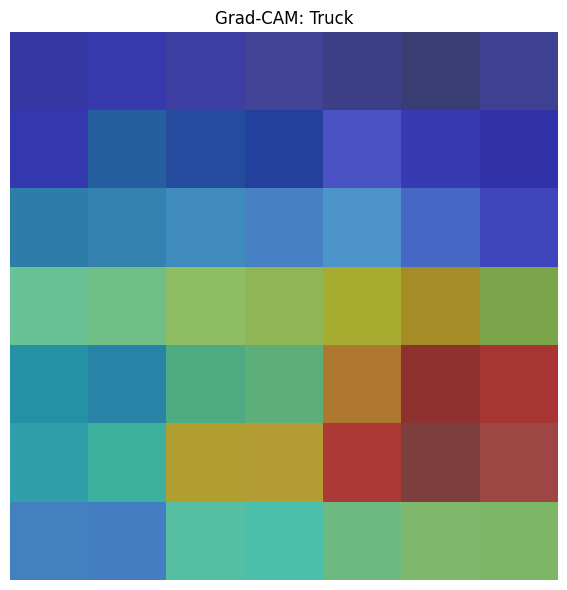

In [61]:
plot_gradcam_from_dict(model, image_dict, category_name='Truck', target_layer=target_layer)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


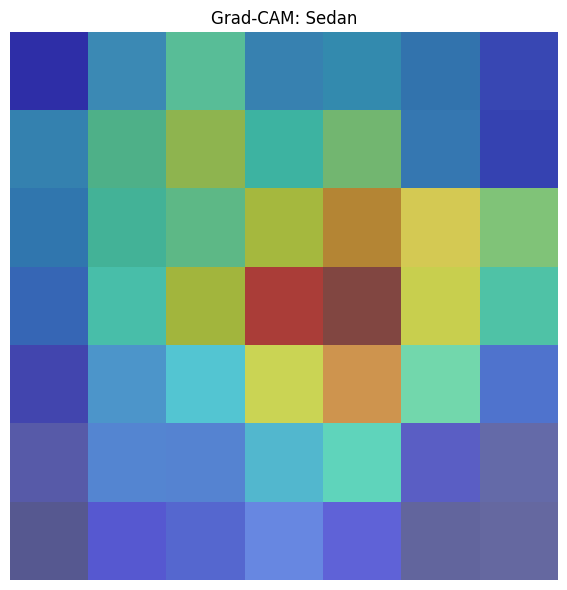

In [65]:
plot_gradcam_from_dict(model, image_dict, category_name='Sedan', target_layer=target_layer)

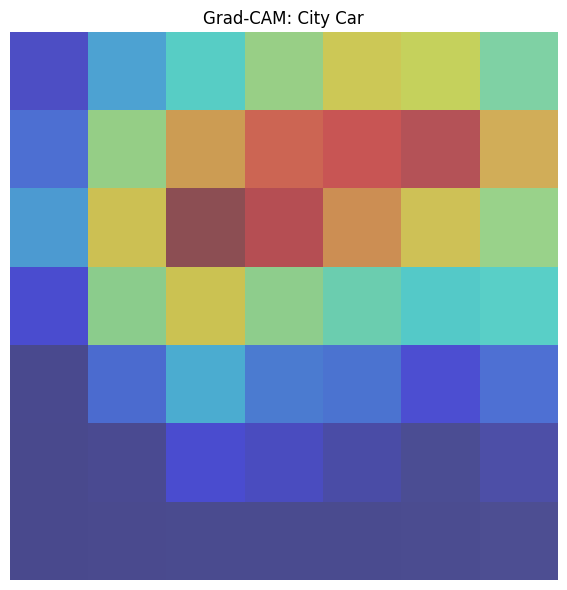

In [66]:
plot_gradcam_from_dict(model, image_dict, category_name='City Car', target_layer=target_layer)

In [68]:
def visualize_filters_from_dict(model, image_dict, category_name, target_layer, num_filters=8):
    if category_name not in image_dict:
        print(f"Category '{category_name}' not found in image_dict.")
        return

    img_path = image_dict[category_name]
    input_tensor, _ = load_image(img_path)

    features = []
    hook = target_layer.register_forward_hook(capture_feature_map(features))
    _ = model(input_tensor)
    hook.remove()

    if not features:
        print(f"No features captured for category '{category_name}'.")
        return

    plot_feature_maps(features[0], num_filters=num_filters, title_prefix=f'{category_name}')

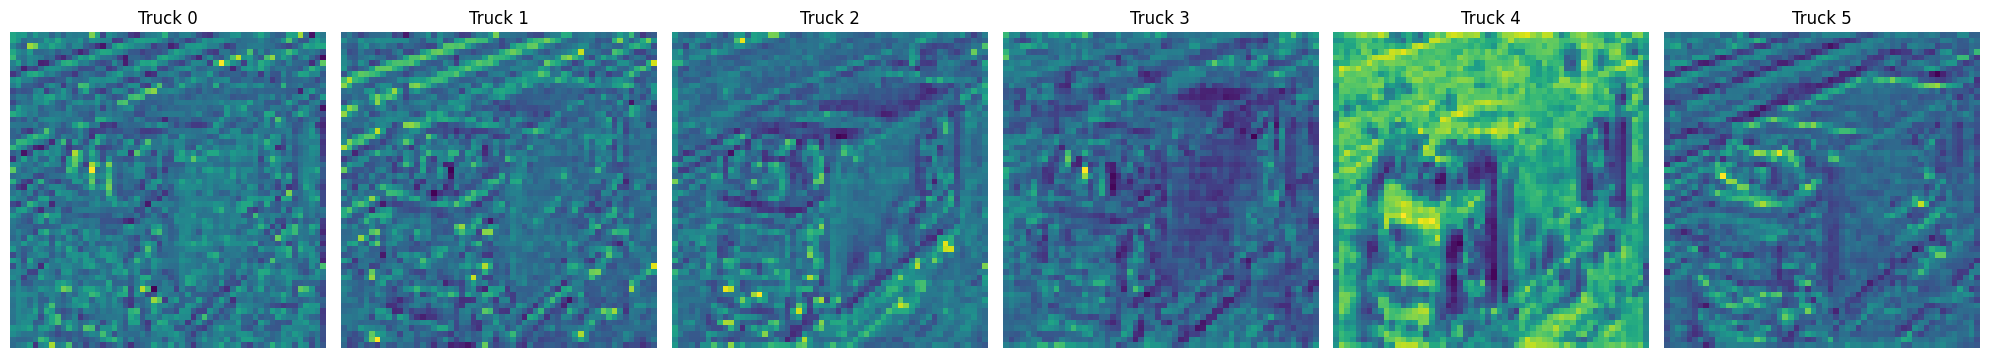

In [72]:
target_layer = model.layer2[0].conv1
visualize_filters_from_dict(model, image_dict, category_name='Truck', target_layer=target_layer, num_filters=6)


In [62]:
layers = {
    'conv1': model.conv1,
    'layer1': model.layer1[0].conv1,
    'layer2': model.layer2[0].conv1,
    'layer3': model.layer3[0].conv1,
    'layer4': model.layer4[0].conv1,
}

In [74]:
def visualize_all_layers_for_category(model, image_dict, category_name, layers_dict, num_filters=6):

    for layer_name, layer_module in layers_dict.items():
        print(f'Visualizing filters from {layer_name} for category "{category_name}"')
        visualize_filters_from_dict(
            model=model,
            image_dict=image_dict,
            category_name=category_name,
            target_layer=layer_module,
            num_filters=num_filters
        )

Visualizing filters from conv1 for category "Truck"


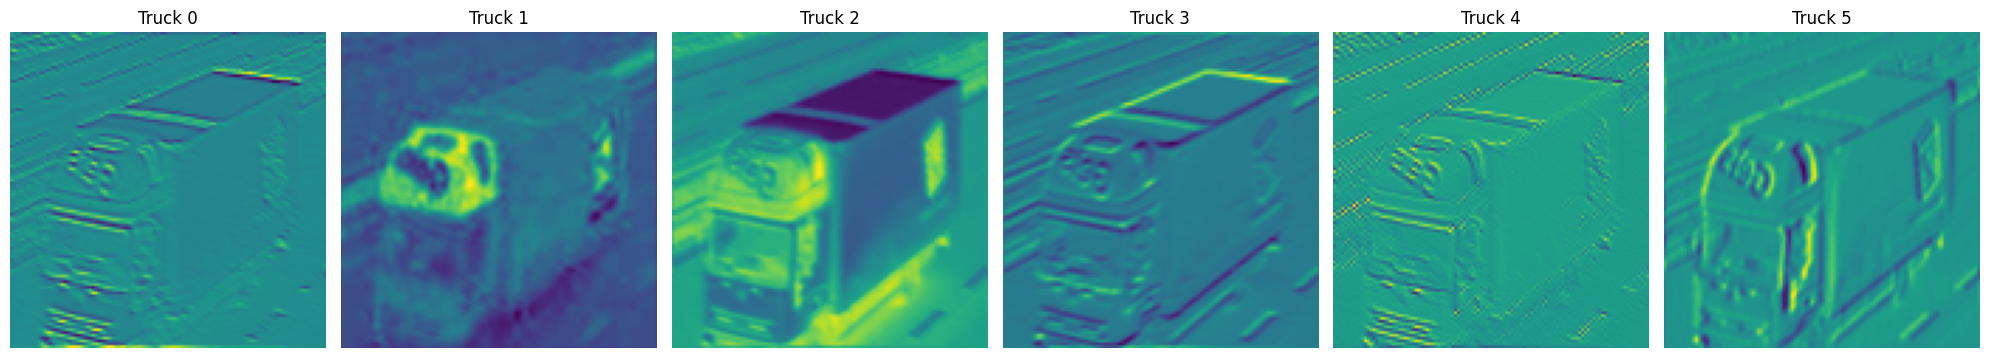

Visualizing filters from layer1 for category "Truck"


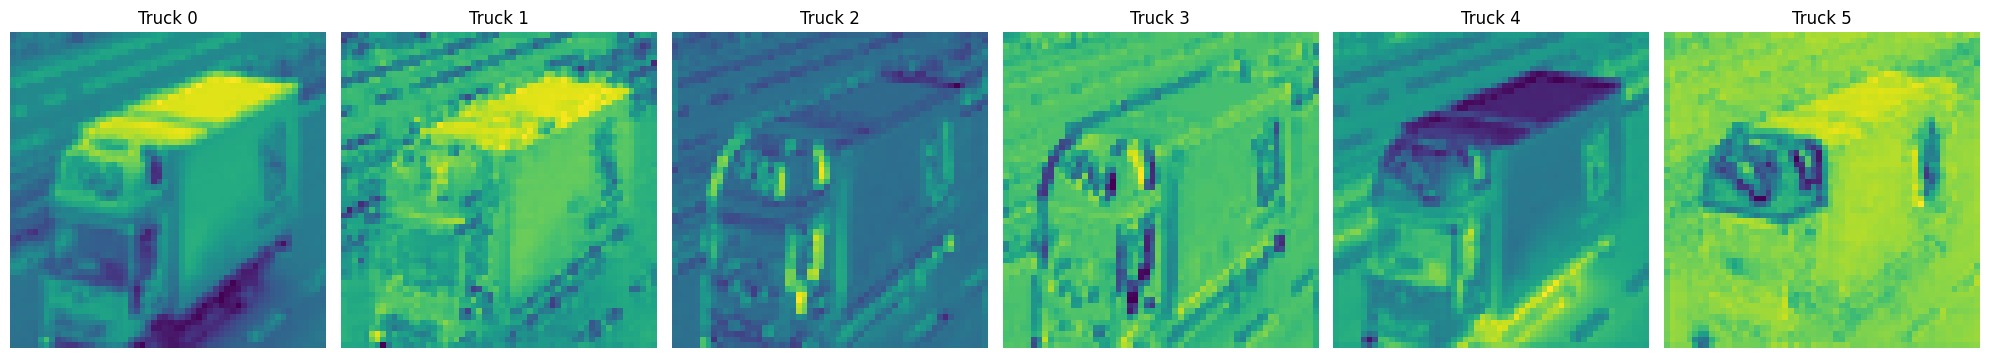

Visualizing filters from layer2 for category "Truck"


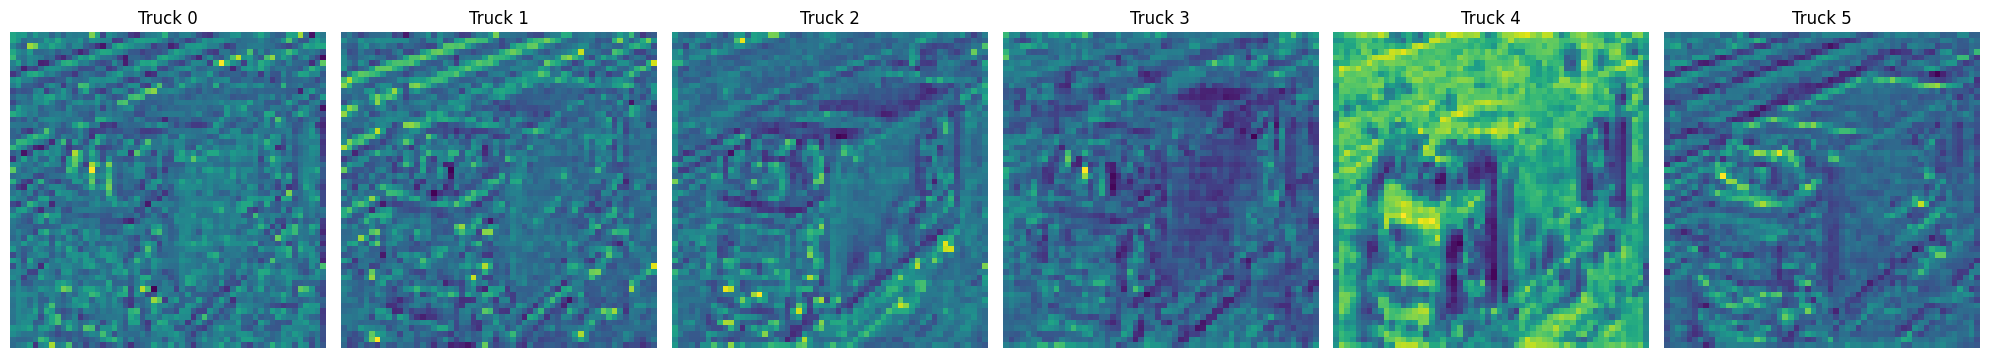

Visualizing filters from layer3 for category "Truck"


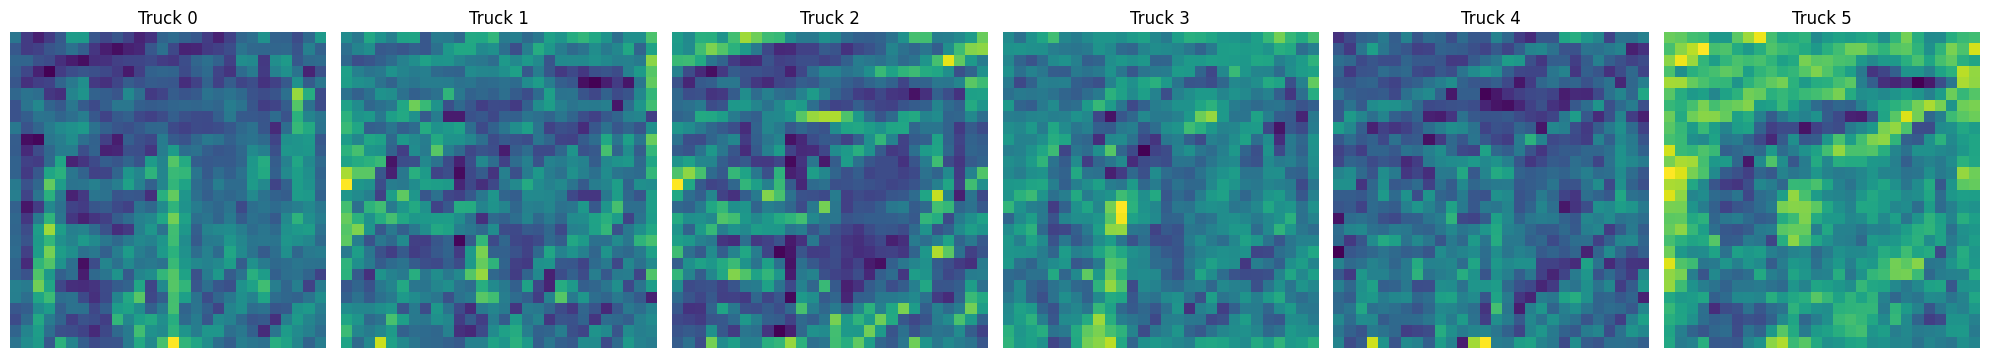

Visualizing filters from layer4 for category "Truck"


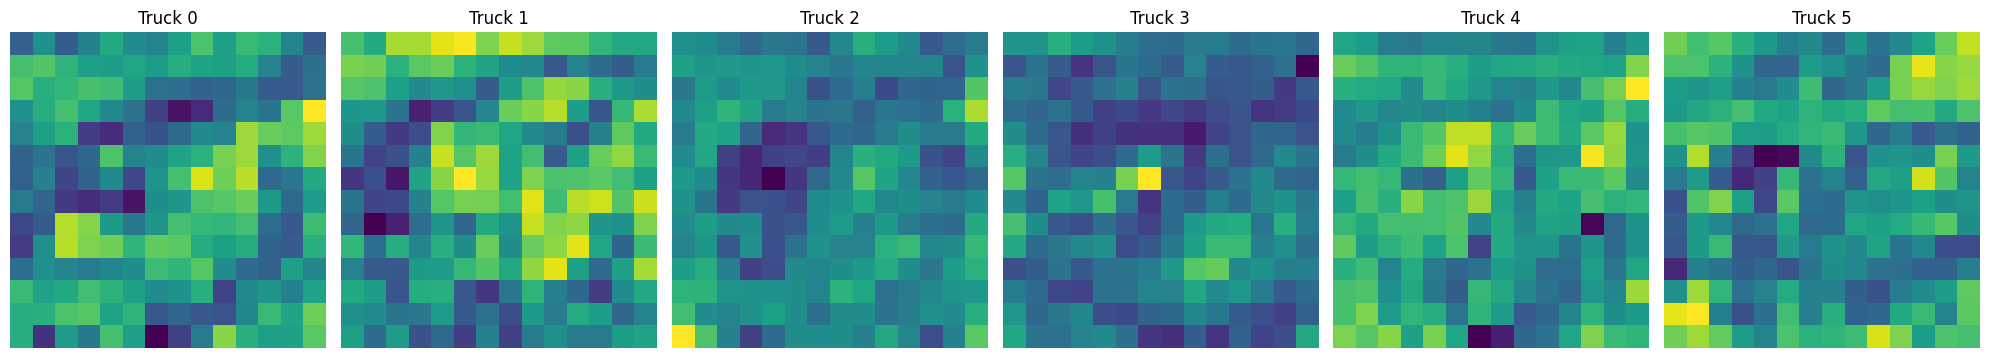

In [75]:
visualize_all_layers_for_category(model, image_dict, category_name='Truck', layers_dict=layers)

Visualizing filters from conv1 for category "Sedan"


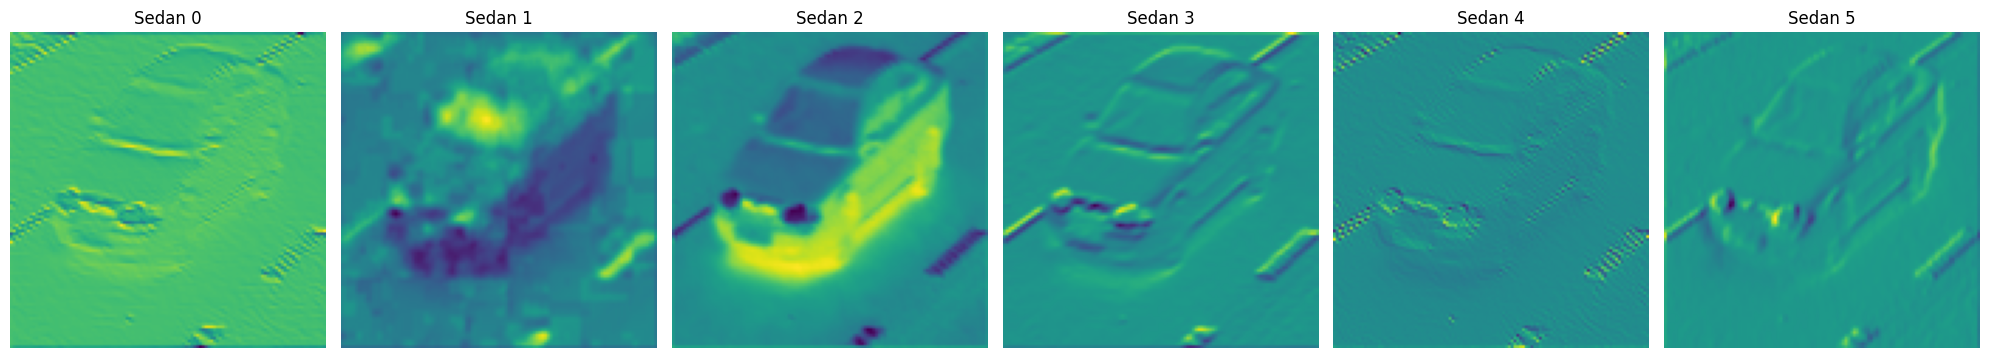

Visualizing filters from layer1 for category "Sedan"


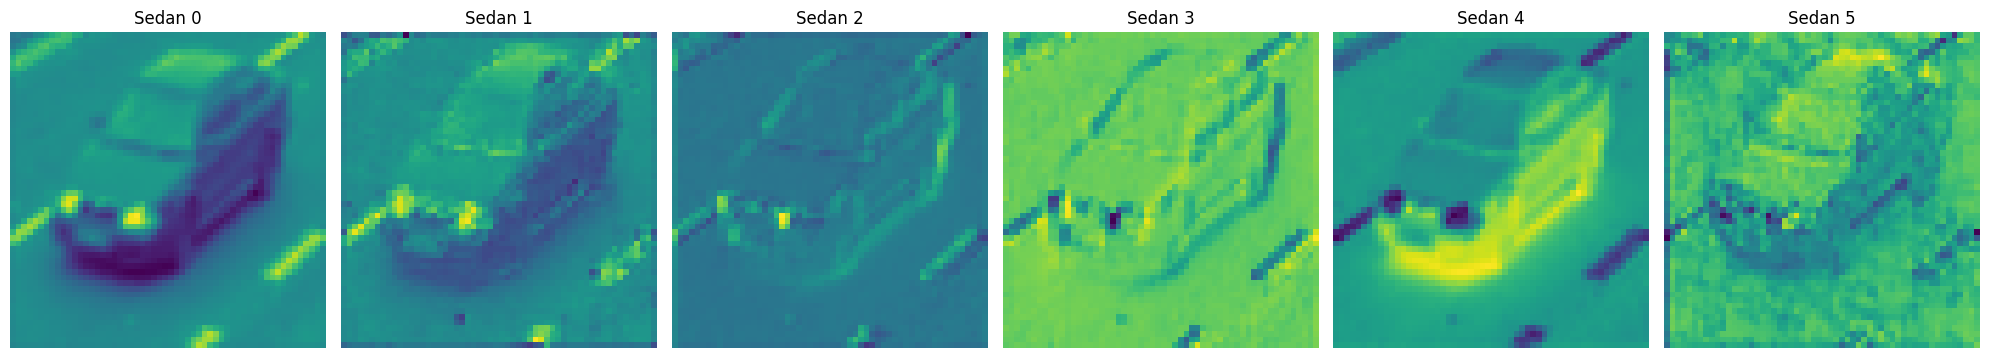

Visualizing filters from layer2 for category "Sedan"


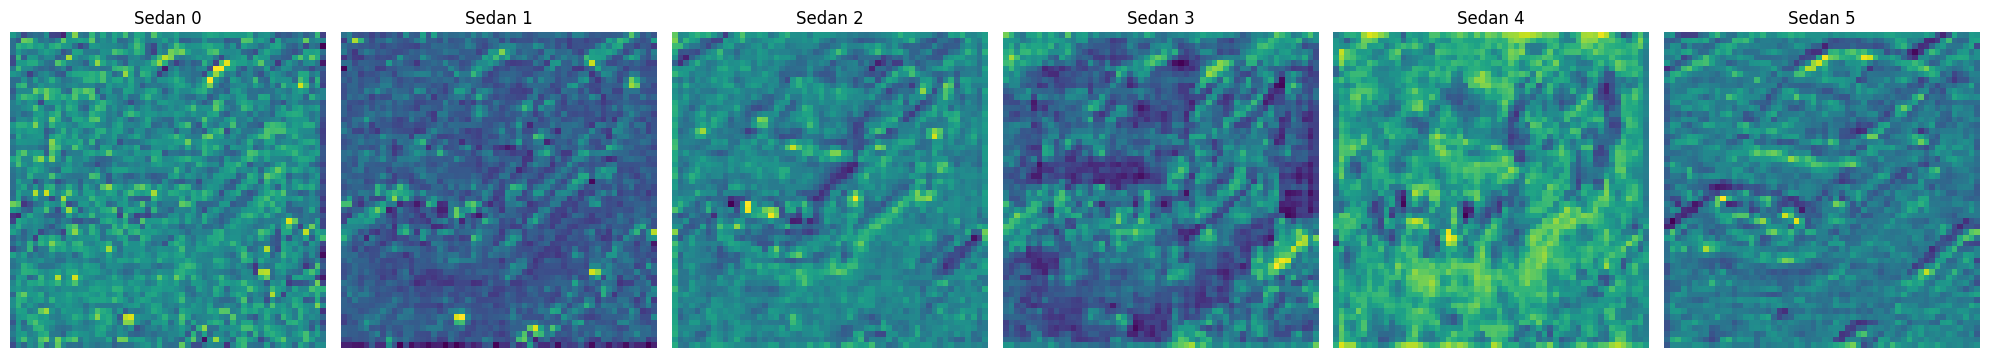

Visualizing filters from layer3 for category "Sedan"


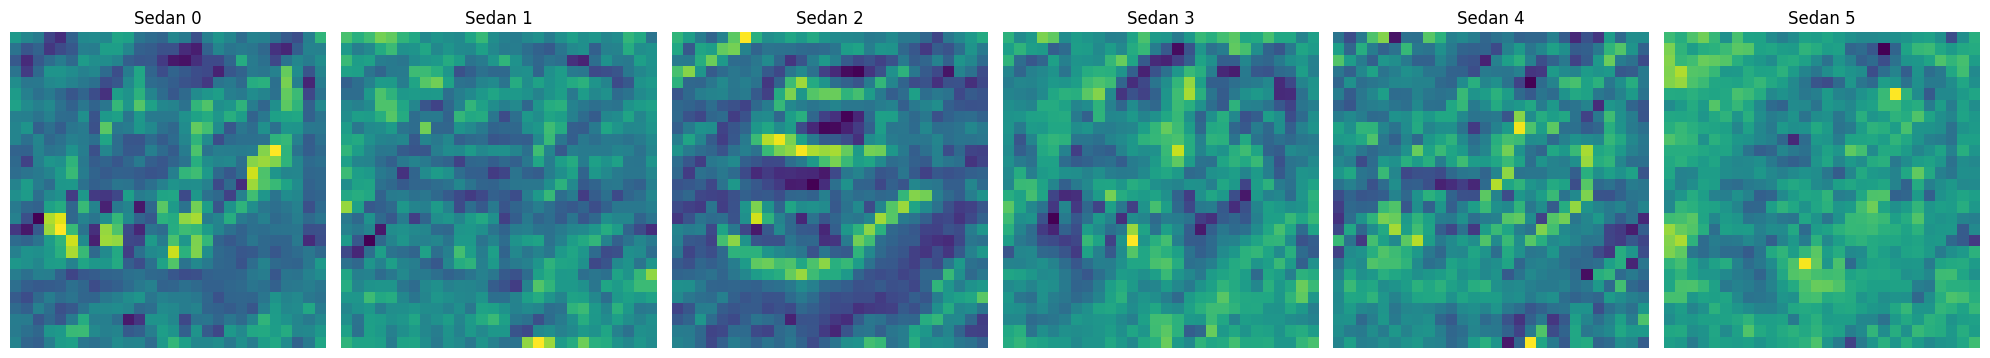

Visualizing filters from layer4 for category "Sedan"


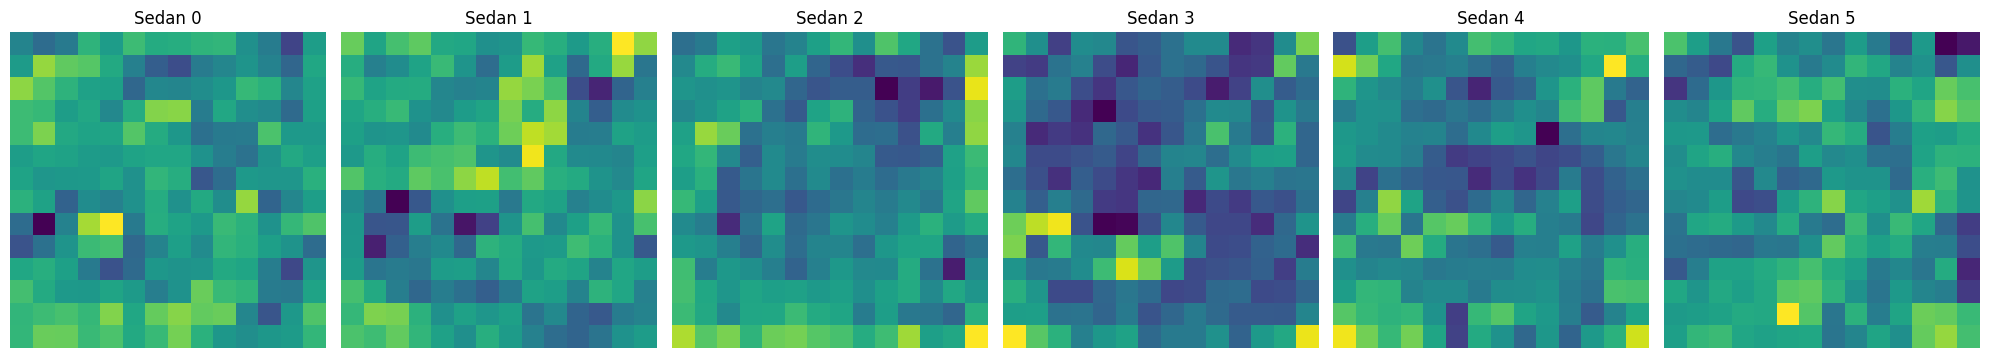

In [76]:
visualize_all_layers_for_category(model, image_dict, category_name='Sedan', layers_dict=layers)

Visualizing filters from conv1 for category "City Car"


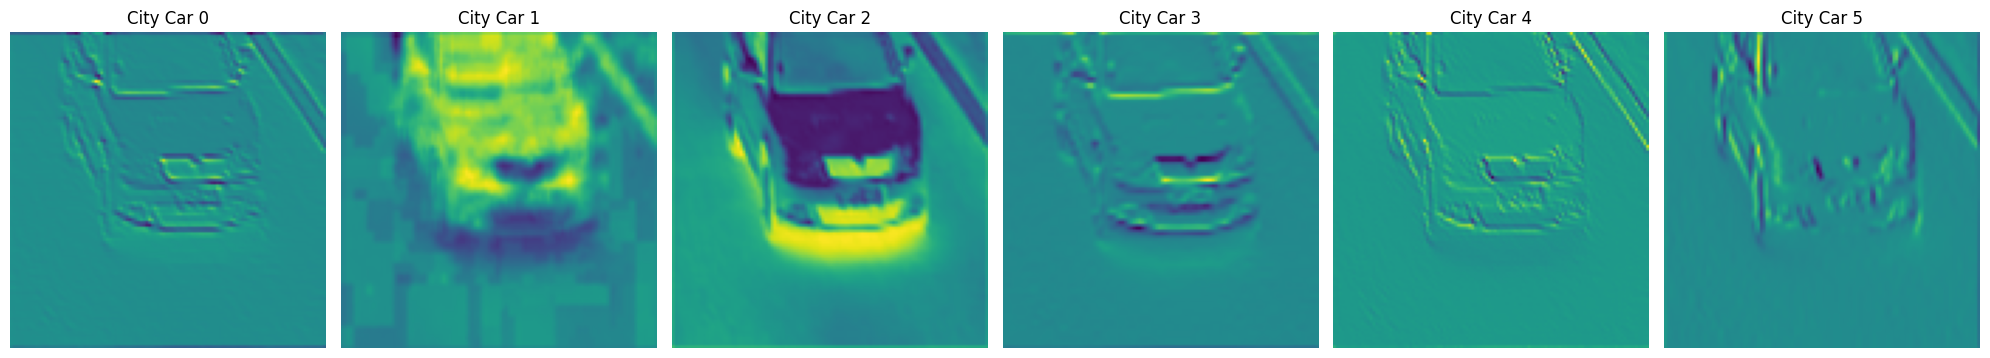

Visualizing filters from layer1 for category "City Car"


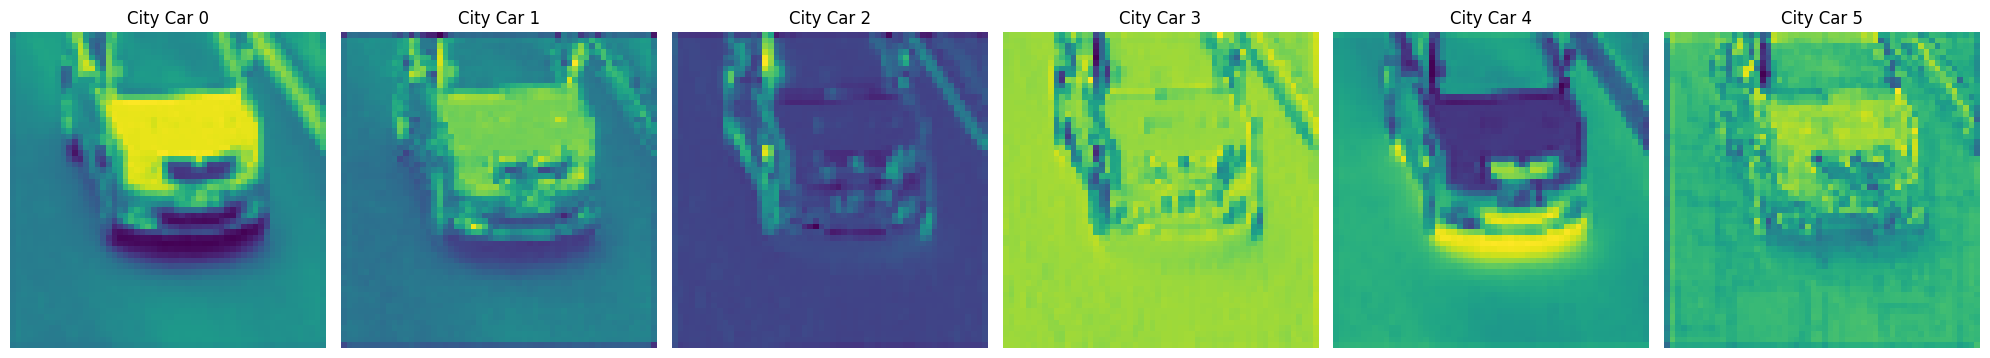

Visualizing filters from layer2 for category "City Car"


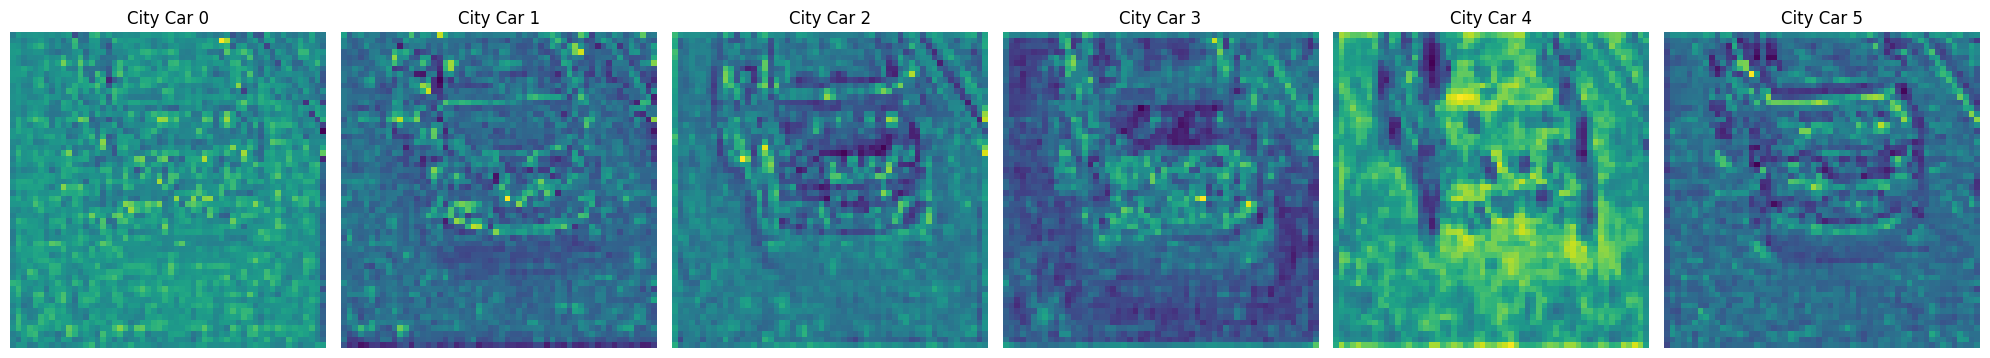

Visualizing filters from layer3 for category "City Car"


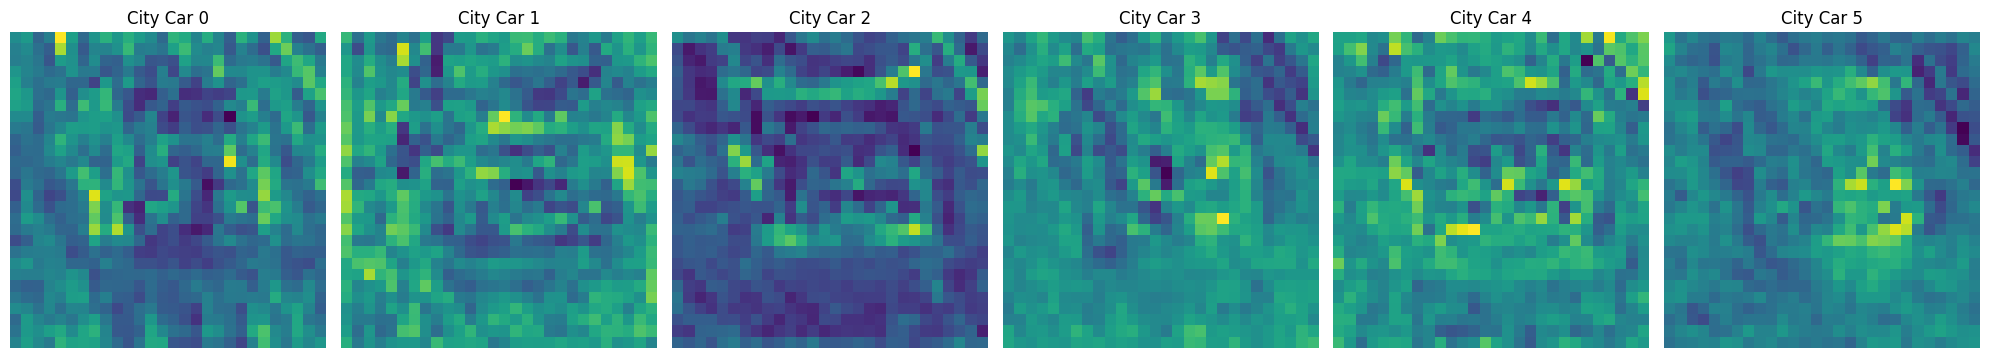

Visualizing filters from layer4 for category "City Car"


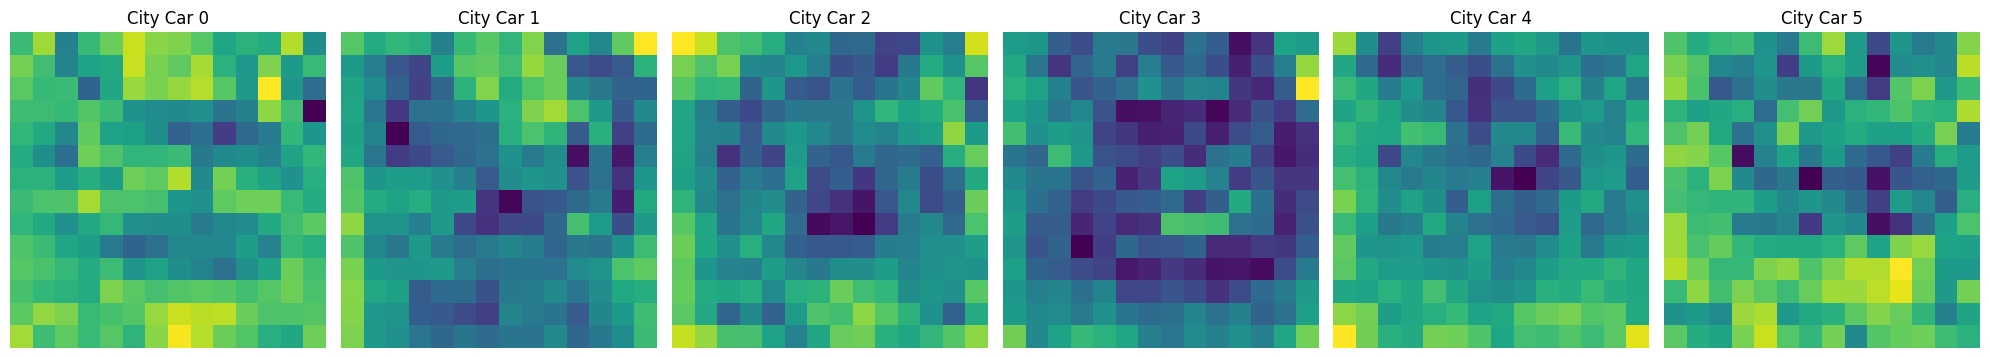

In [77]:
visualize_all_layers_for_category(model, image_dict, category_name='City Car', layers_dict=layers)

Visualizing filters from conv1 for category "Multi Purpose Vehicle"


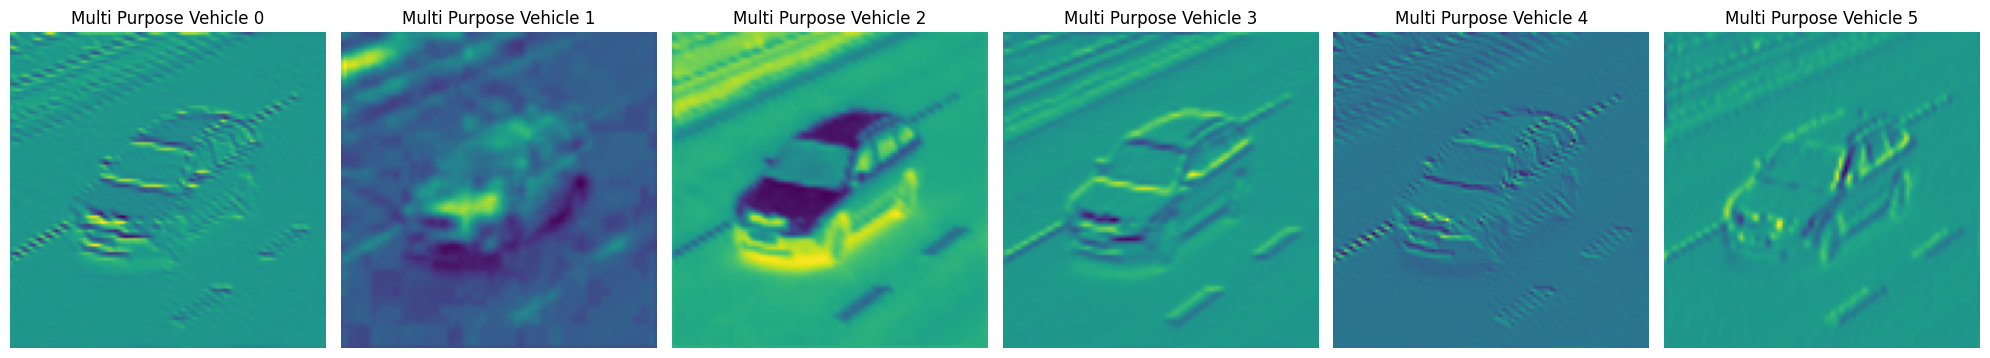

Visualizing filters from layer1 for category "Multi Purpose Vehicle"


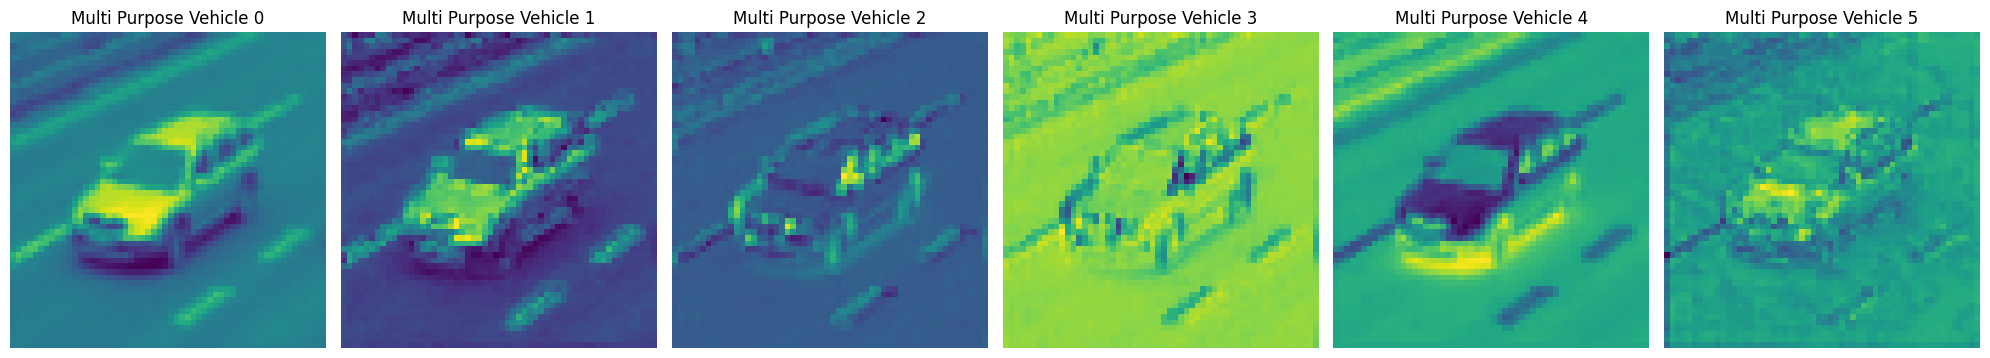

Visualizing filters from layer2 for category "Multi Purpose Vehicle"


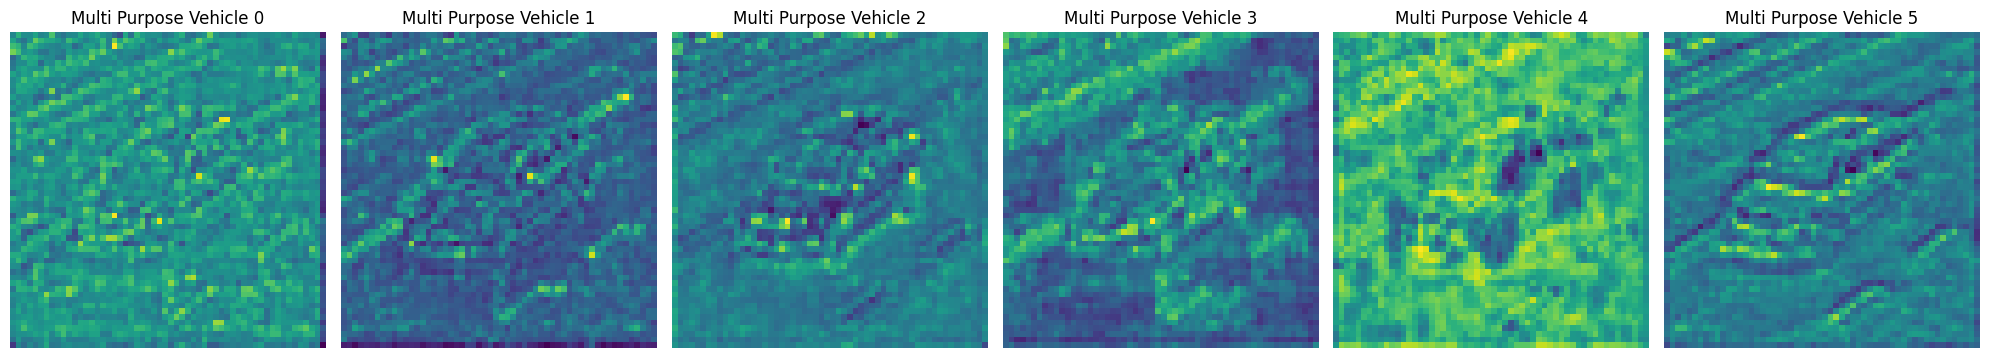

Visualizing filters from layer3 for category "Multi Purpose Vehicle"


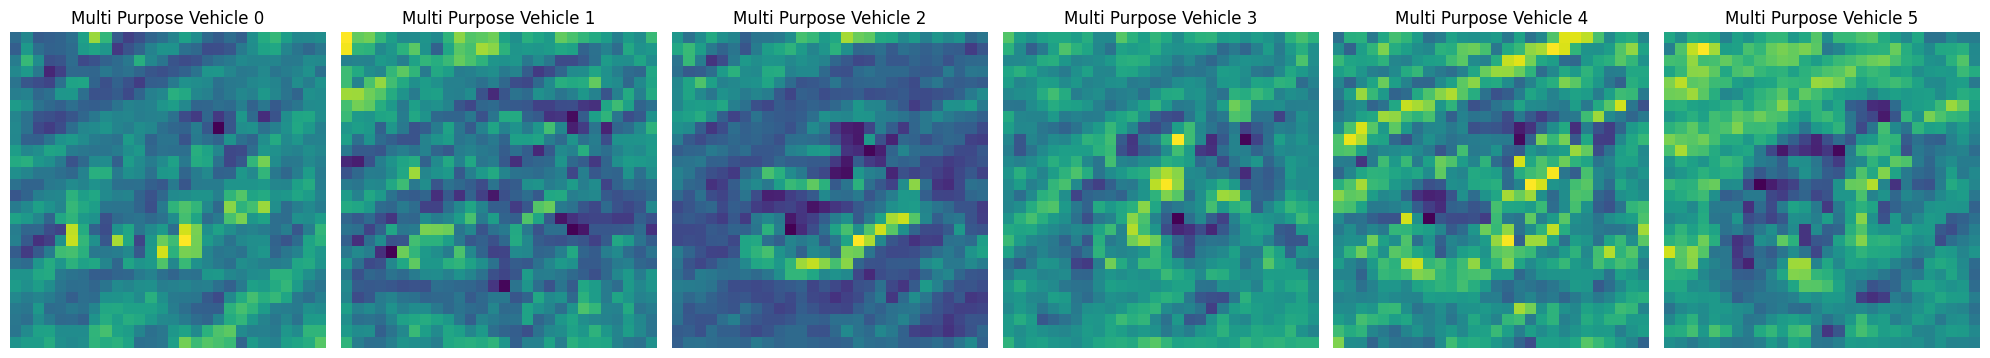

Visualizing filters from layer4 for category "Multi Purpose Vehicle"


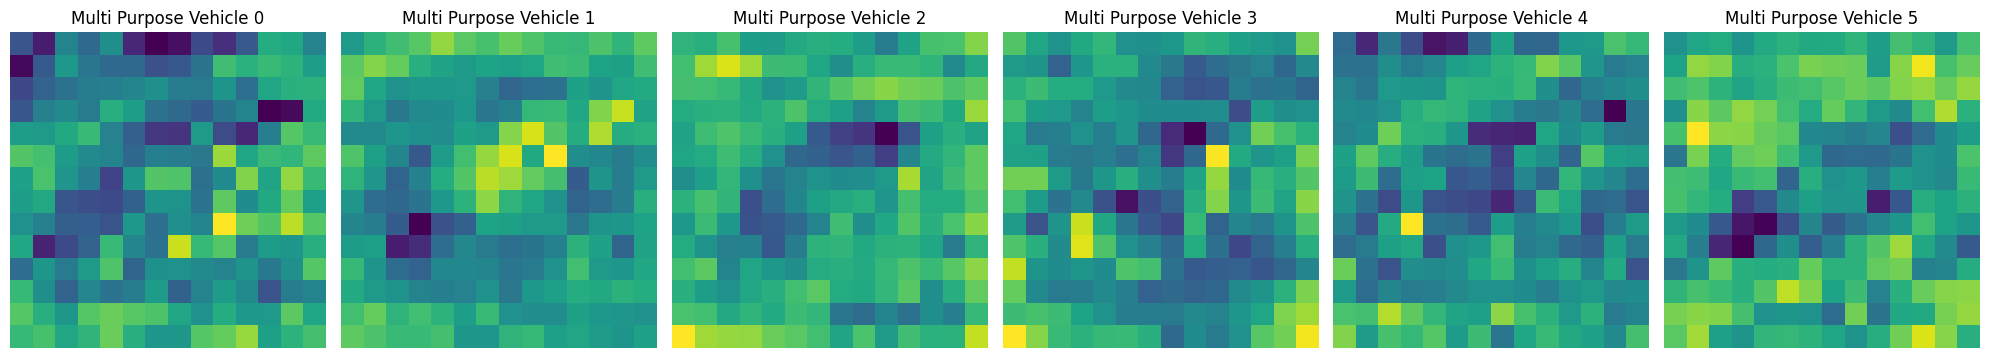

In [78]:
visualize_all_layers_for_category(model, image_dict, category_name='Multi Purpose Vehicle', layers_dict=layers)

Visualizing filters from conv1 for category "Sport Utility Vehicle"


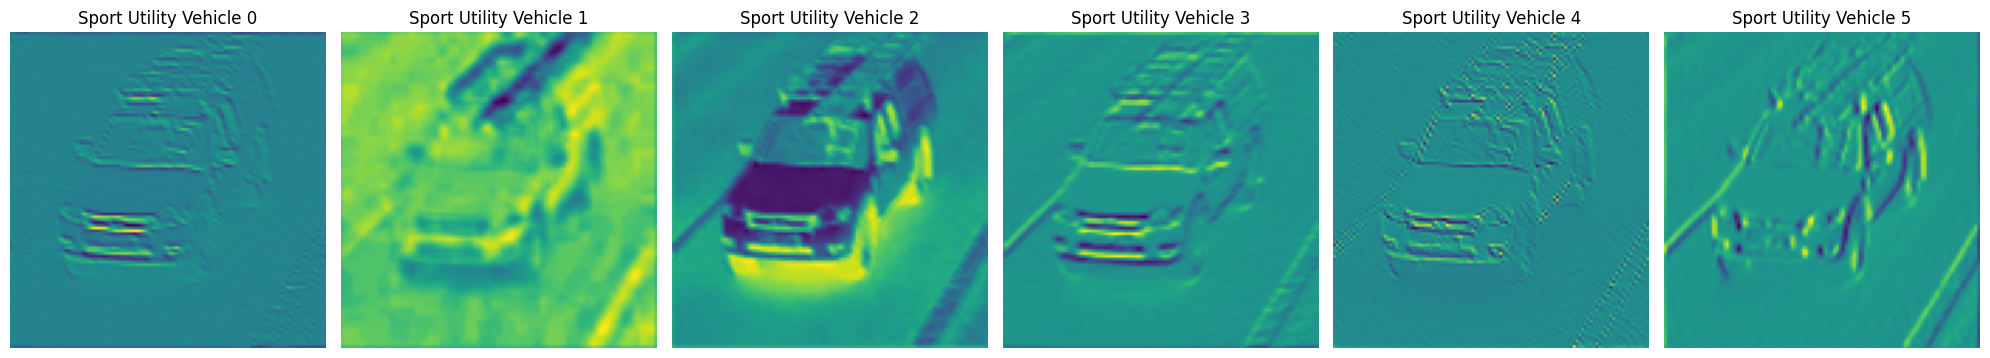

Visualizing filters from layer1 for category "Sport Utility Vehicle"


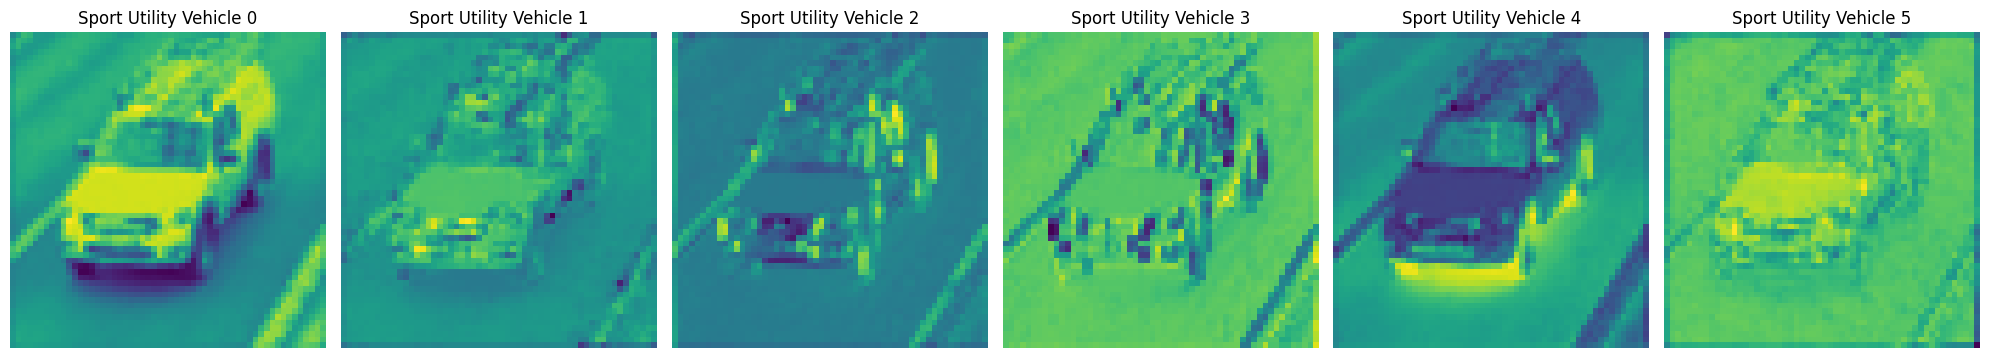

Visualizing filters from layer2 for category "Sport Utility Vehicle"


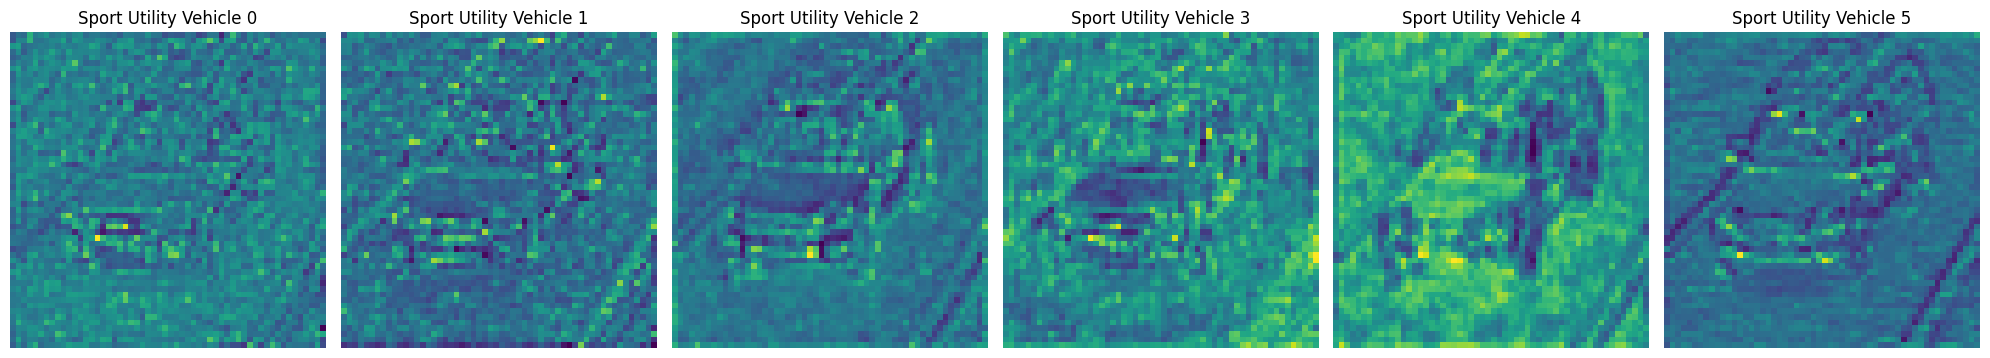

Visualizing filters from layer3 for category "Sport Utility Vehicle"


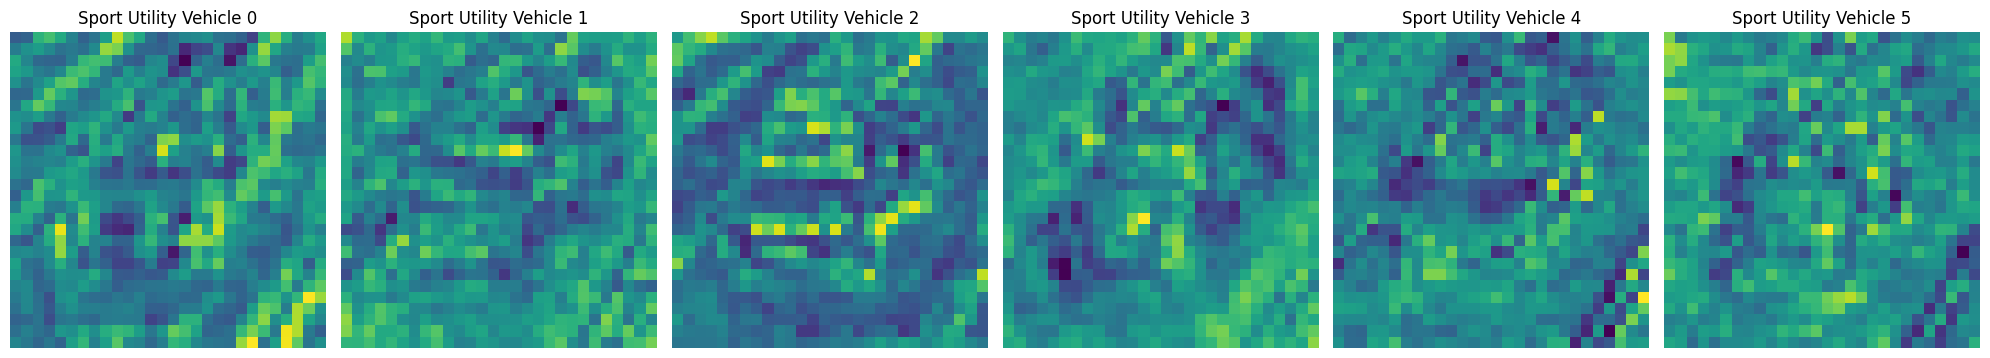

Visualizing filters from layer4 for category "Sport Utility Vehicle"


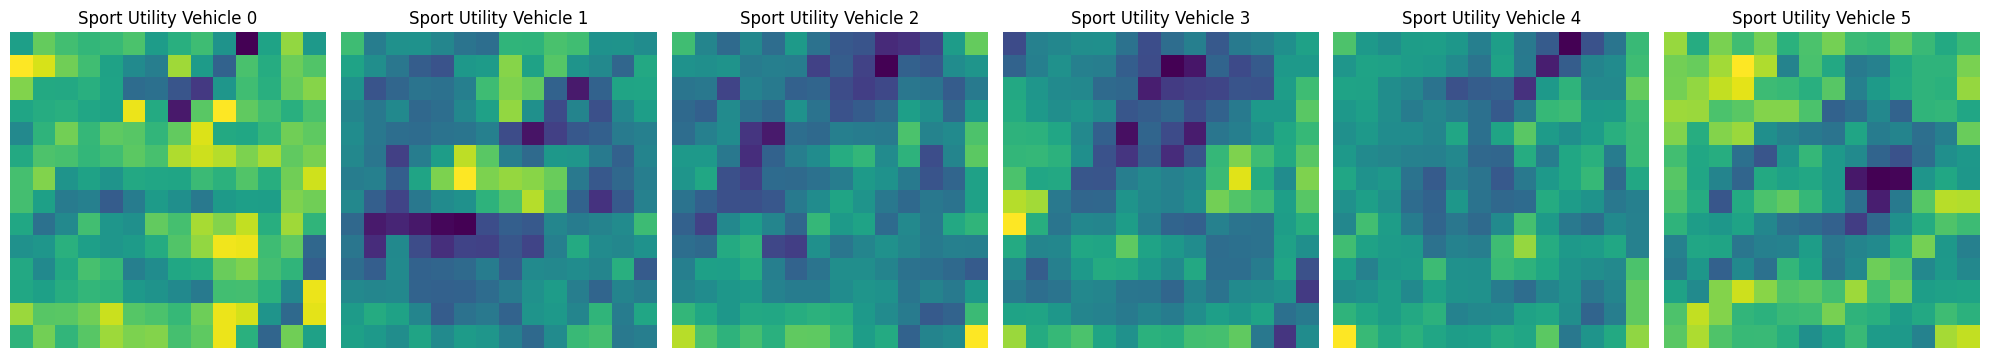

In [80]:
visualize_all_layers_for_category(model, image_dict, category_name='Sport Utility Vehicle', layers_dict=layers)

Visualizing filters from conv1 for category "Van"


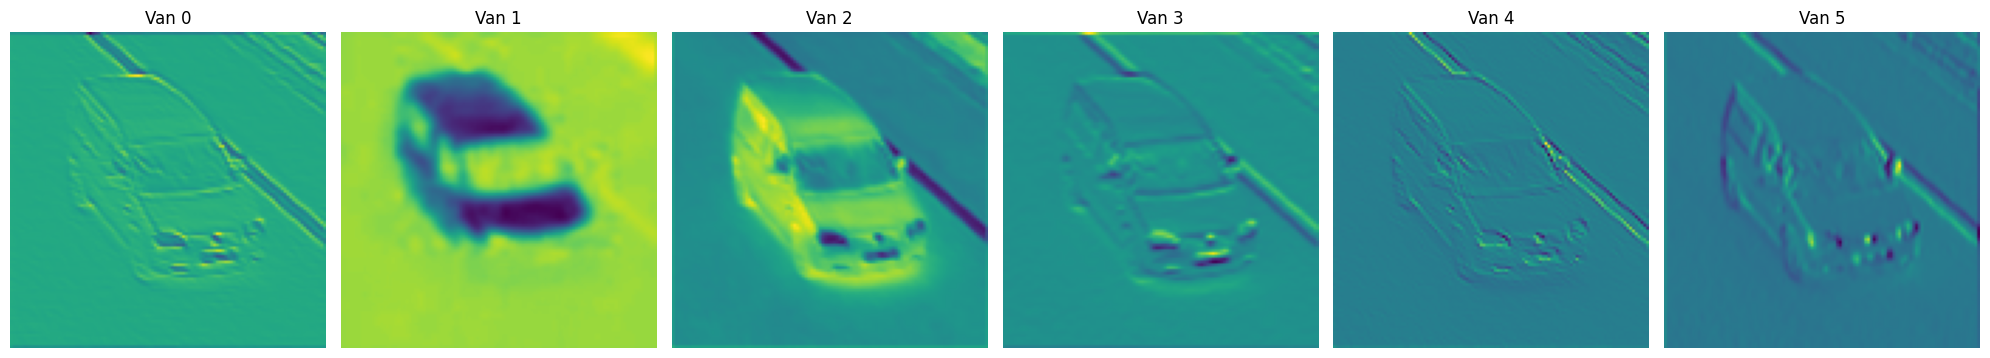

Visualizing filters from layer1 for category "Van"


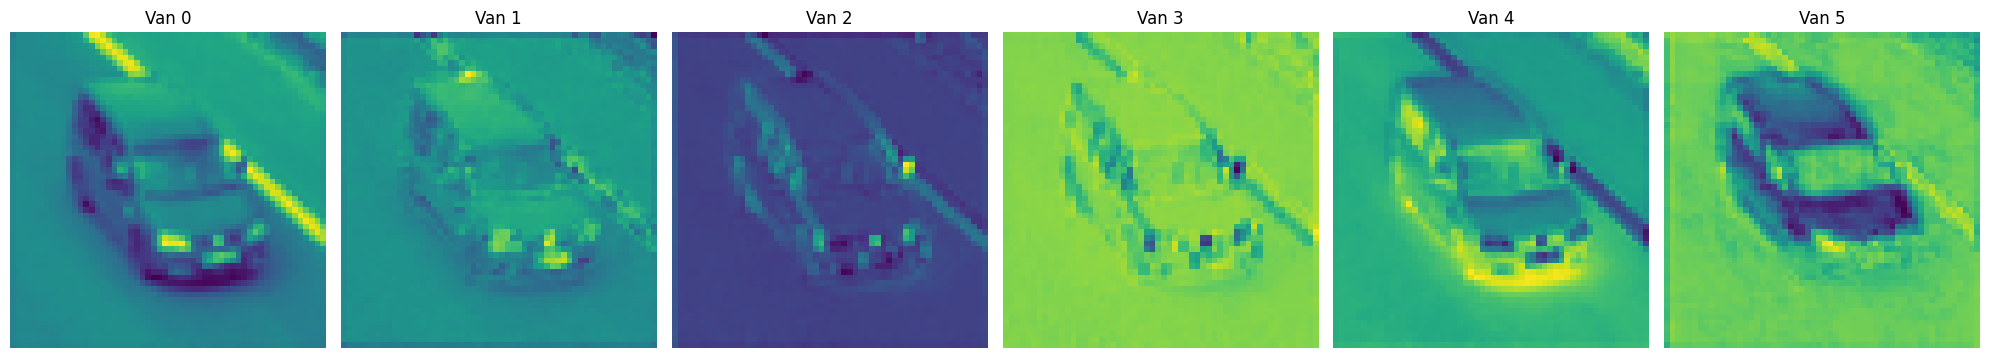

Visualizing filters from layer2 for category "Van"


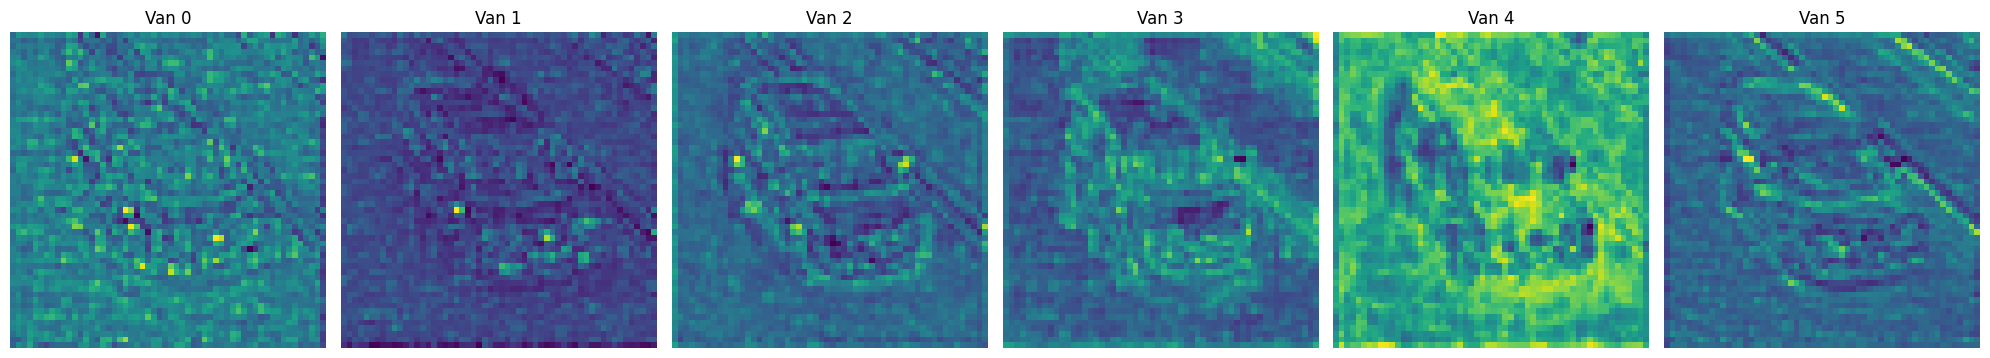

Visualizing filters from layer3 for category "Van"


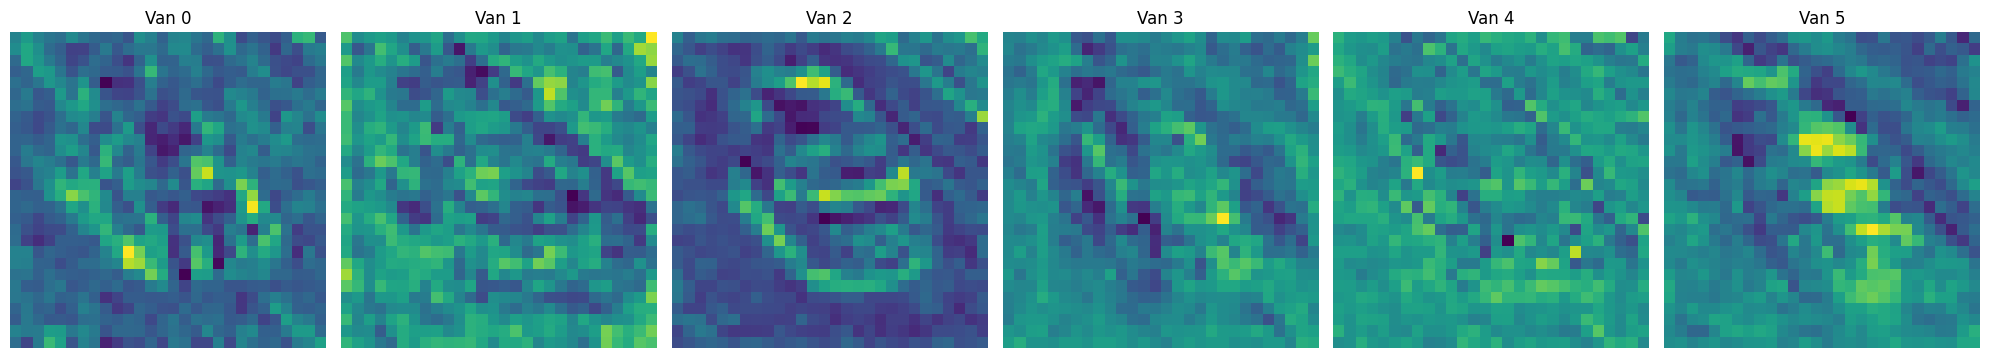

Visualizing filters from layer4 for category "Van"


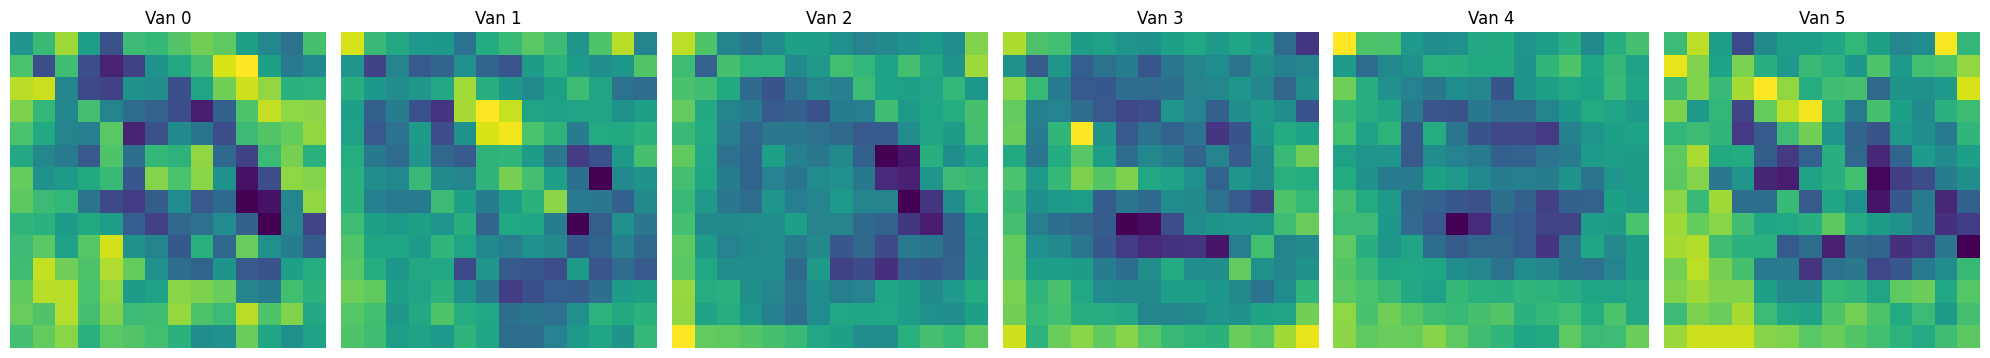

In [81]:
visualize_all_layers_for_category(model, image_dict, category_name='Van', layers_dict=layers)

Visualizing filters from conv1 for category "Big Truck"


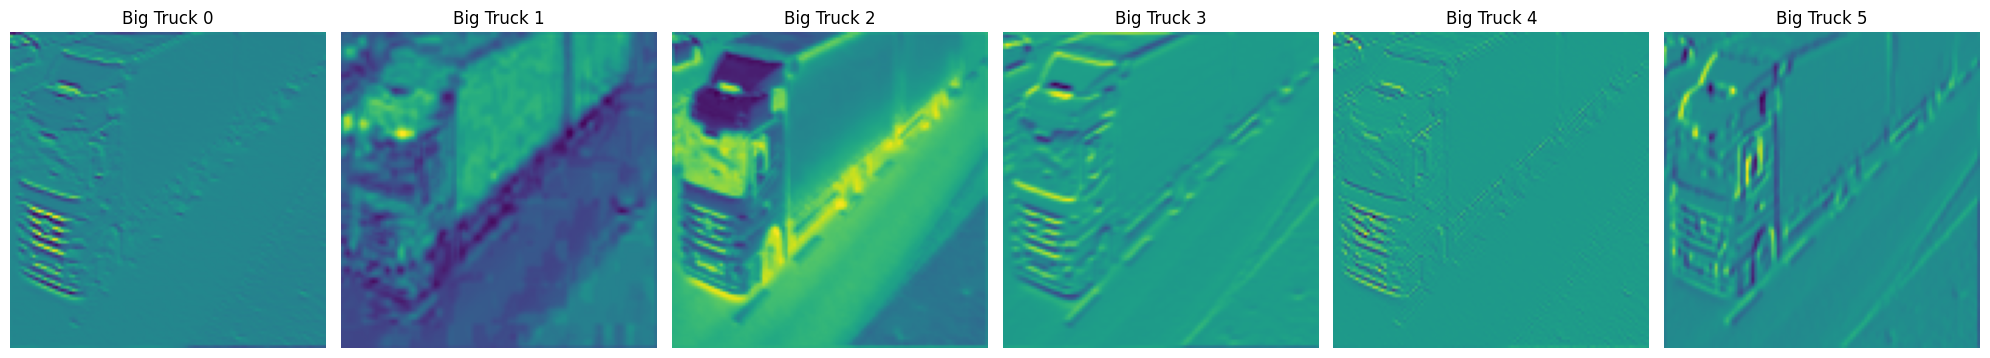

Visualizing filters from layer1 for category "Big Truck"


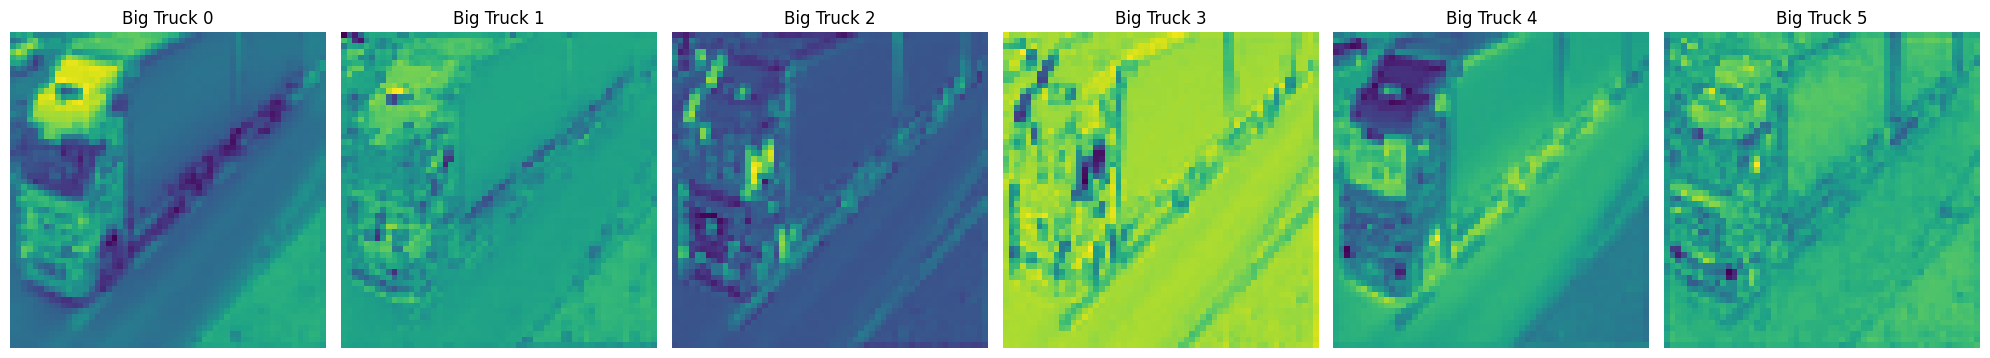

Visualizing filters from layer2 for category "Big Truck"


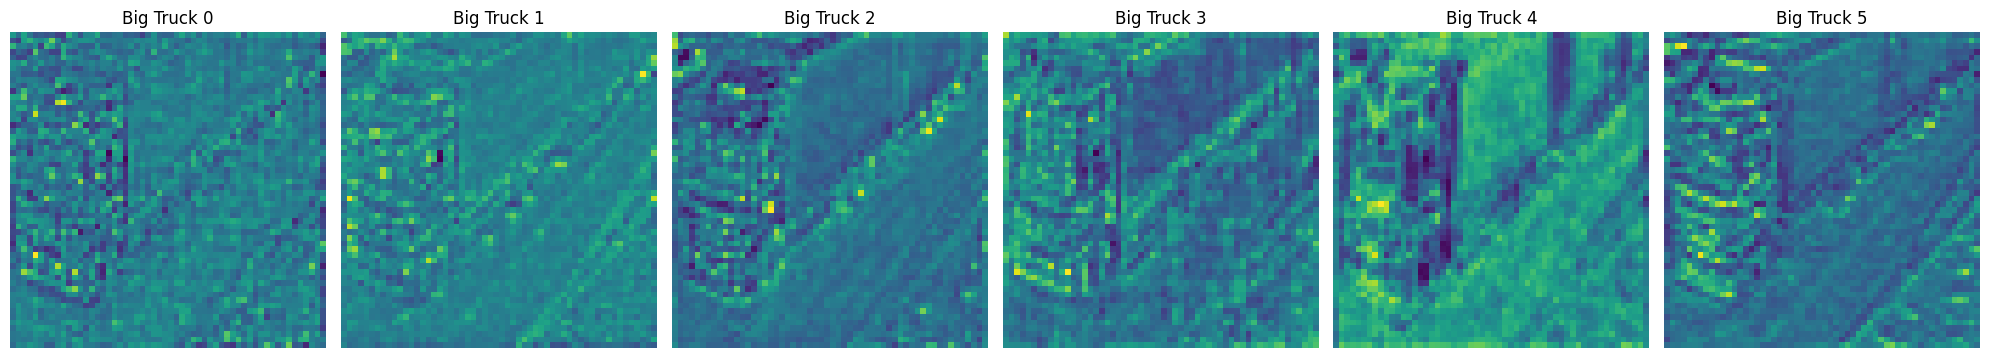

Visualizing filters from layer3 for category "Big Truck"


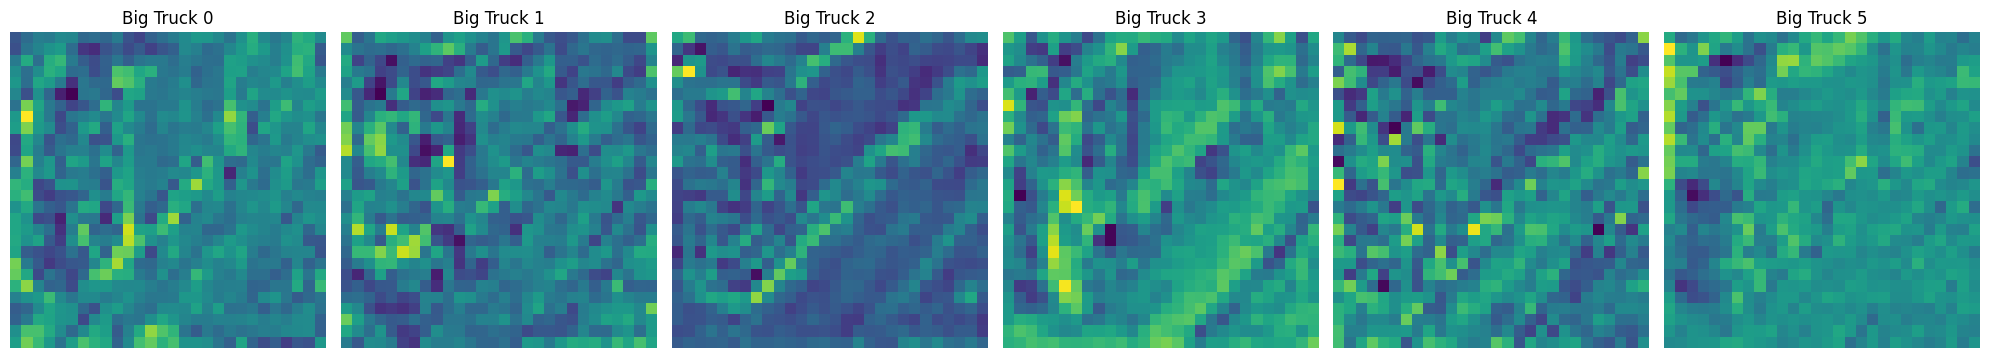

Visualizing filters from layer4 for category "Big Truck"


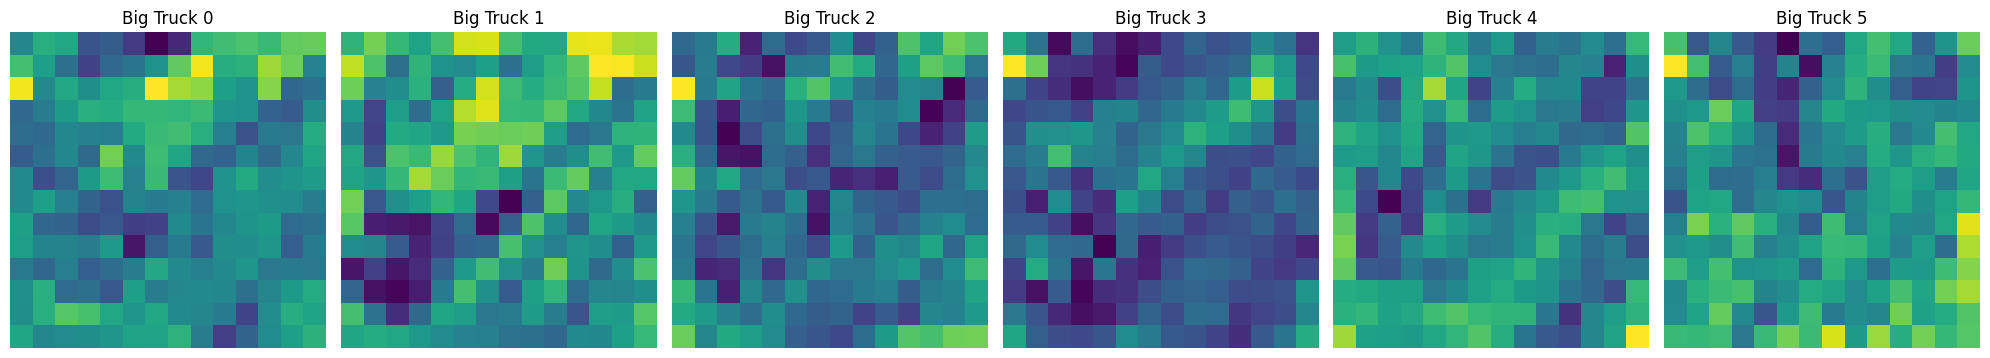

In [82]:
visualize_all_layers_for_category(model, image_dict, category_name='Big Truck', layers_dict=layers)